# 07 · News decomposition: why did the nowcast change?

A nowcast that moves without explanation is of little use to a policy committee.
Bańbura & Modugno (2014), building on Bańbura, Giannone & Reichlin (2011), showed that
in a linear Gaussian state-space model the revision of a nowcast between two data
vintages $\Omega_v \subset \Omega_{v+1}$ is an exact weighted sum of **news**:

$$
\mathbb{E}[y_t \mid \Omega_{v+1}] - \mathbb{E}[y_t \mid \Omega_v]
= \sum_{j \in I_{v+1}} b_j \left(x_j - \mathbb{E}[x_j \mid \Omega_v]\right),
$$

where the sum runs over the newly released observations $x_j$, the term in brackets
is the **surprise** (actual minus what the model expected) and $b_j$ is a **weight**
reflecting how informative the series is about the target given everything already
known. When old observations are also revised, the change splits into a *revisions*
effect and a *news* effect; when the parameters are re-estimated, a third
*re-estimation* term appears. `nowcastbox` computes all three exactly (innovation I6)
and aggregates the news by series, block or category (hard / soft / financial).

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

from utils import (
    brazil_panel,
    brazil_realtime_store,
    display,
    md,
    pct,
    setup,
    show,
    store_metadata,
)

import nowcastbox as nb

setup()

## 1. Model and vintages

The compact Brazilian panel (GDP + 21 monthly indicators) with **blocks**: every
series loads on a global factor, and on a real, nominal, financial or soft (Focus
survey) factor, according to the dataset metadata. Pseudo real-time vintages use the
actual GDP release dates and typical delays of the indicators
(`load_brazil_calendar`).

In [2]:
ds, panel = brazil_panel(start="2005-01")
calendar = nb.load_brazil_calendar()
display(panel.blocks.astype(int).sum().rename("series").to_frame().T)

old = nb.pseudo_real_time(panel, calendar=calendar, vintage="2026-08-15")
new = nb.pseudo_real_time(panel, calendar=calendar, vintage="2026-09-15")
model = nb.MixedFreqDFM(n_factors=1, factor_lags=1, blocks="data")
res = model.fit(new, target="pib")
print(res.summary(n_periods=4))

,global,real,nominal,financial,soft
series,22,15,1,4,2


                        Nowcast Results: MixedFreqDFM
Target:                 pib (quarterly)
Sample:                 2005-02 .. 2026-09
Series:                 22
Factors:                5
Log-likelihood:         -6200.0470
Iterations:             8
Converged:              True
------------------------------------------------------------------------------
Model parameters
  n_factors             1
  factor_lags           1
  blocks                data
  idiosyncratic         ar1
  max_iter              500
  tol                   0.0001
  init                  pca
  obs_noise_var         0.0001
  filter_method         auto
  df                    -
  outliers              none
  outlier_threshold     4.0000
  exclude_periods       -
  covid                 none
  covid_window          ('2020-03', '2021-12')
  long_run_mean         constant
  long_run_series       -
  long_run_variance     -
------------------------------------------------------------------------------
Factor dynamics


## 2. One month of news: 15 August → 15 September 2026

The target is GDP growth in 2026Q3. `res.news(old, new, period)` uses the parameters
of `res` to compute the expectations under both information sets.

In [3]:
news = res.news(old, new, target_period="2026Q3")
print(news.summary())
assert news.check_identity()  # old + revisions + news + re-estimation == new

News decomposition: pib 2026Q3 (MixedFreqDFM)
  Old nowcast                    -0.000995
  Data revisions                  0.000000
  News (new releases)             0.001319
  Re-estimation                   0.000000
  New nowcast                     0.000325
  Releases / revised             22 / 0
------------------------------------------------------------------------------
  category                            news     revisions         total
  hard                            0.001378      0.000000      0.001378
  soft                            0.000047      0.000000      0.000047
  financial                      -0.000106      0.000000     -0.000106
------------------------------------------------------------------------------
  release                         actual    expected      weight      impact
  pim_transformacao 2026-07       0.0052      0.0019      0.2437      0.0008
  pim_bens_consumo_duraveis       0.0317      0.0004      0.0098      0.0003
  anp_diesel 2026-07      

In [4]:
top = news.top_releases(8)
display(top[["series", "reference_period", "actual", "expected", "weight", "impact"]])

,series,reference_period,actual,expected,weight,impact
3,pim_transformacao,2026-07,0.0052,0.0019,0.2437,0.0008
5,pim_bens_consumo_duraveis,2026-07,0.0317,0.0004,0.0098,0.0003
11,anp_diesel,2026-07,-0.0033,0.0222,0.0076,-0.0002
14,secex_importacoes_bk,2026-08,0.2570,0.0722,0.0010,0.0002
10,energia_consumo_industria,2026-07,0.0077,-0.0050,0.0113,0.0001
13,secex_exportacoes,2026-08,0.1149,0.0461,0.0020,0.0001
6,pmc_varejo,2026-07,-0.0085,0.0015,0.0124,-0.0001
1,ibc_br,2026-07,-0.0022,0.0026,0.0230,-0.0001


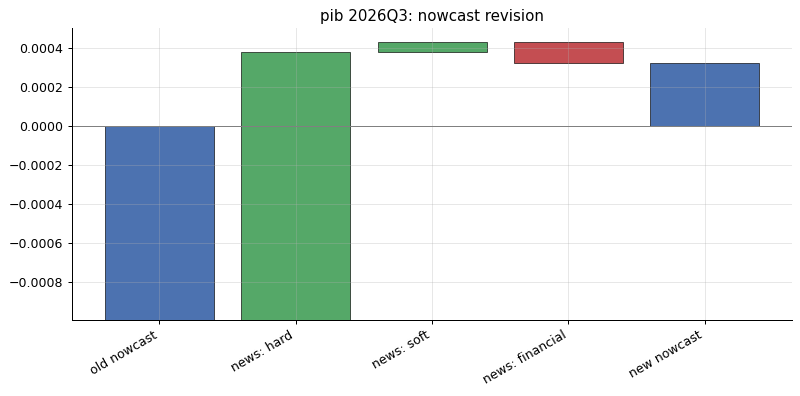

In [5]:
fig = news.plot("waterfall", by="category")
show(fig, "07_waterfall_category")

**Reading the table.** The `impact` column is `weight × (actual − expected)`. July
manufacturing output came in well above what the model expected and carries a large
weight, so it is the main upward driver of the 2026Q3 nowcast. August inflation was
much lower than expected; its weight is negative, so a negative price surprise
*raises* the GDP nowcast — in this reduced-form model lower inflation goes together
with stronger real activity (real income gains in a disinflation driven by food and
fuel prices). The Focus survey's expected GDP growth was revised down, pulling the
nowcast down slightly: the *soft* contribution is negative. The weights are not
causal effects; they are the regression coefficients of the target on the surprises.

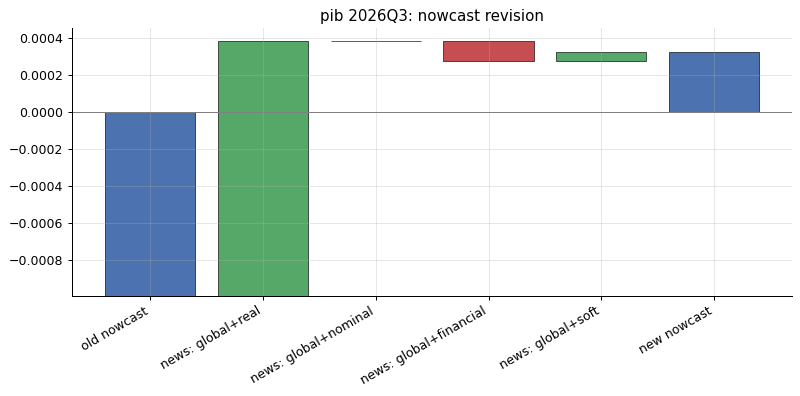

,news,revisions,total
block,,,
global+real,1.3781e-03,0.0,1.3781e-03
global+nominal,-1.3908e-08,0.0,-1.3908e-08
global+financial,-1.0583e-04,0.0,-1.0583e-04
global+soft,4.7158e-05,0.0,4.7158e-05


In [6]:
fig = news.plot("waterfall", by="block")
show(fig, "07_waterfall_block")
display(news.to_frame("block"))

## 3. News *and* revisions: a GDP release day

On 1 September 2026 IBGE published 2026Q2 GDP and, as always, revised the previous
quarters. With the real-time store (pseudo real-time indicators + real GDP vintages,
notebook 06), the vintages before and after that release differ in two ways: a new
observation (2026Q2) and revised old ones. The decomposition separates the two.

In [7]:
store = brazil_realtime_store(panel, calendar)
meta = store_metadata(panel)  # release delays, blocks and categories of the panel
before = store.as_of("2026-08-31", as_mixed=True, **meta)
after = store.as_of("2026-09-02", as_mixed=True, **meta)
res_rt = model.fit(after, target="pib")
release_day = res_rt.news(before, after, target_period="2026Q3")
print(release_day.summary())

News decomposition: pib 2026Q3 (MixedFreqDFM)
  Old nowcast                    -0.003972
  Data revisions                 -0.000000
  News (new releases)             0.000199
  Re-estimation                   0.000000
  New nowcast                    -0.003773
  Releases / revised              4 / 1
------------------------------------------------------------------------------
  category                            news     revisions         total
  hard                            0.000211     -0.000000      0.000211
  financial                      -0.000012      0.000000     -0.000012
------------------------------------------------------------------------------
  release                         actual    expected      weight      impact
  pib 2026Q2                      0.0046      0.0039      0.2045      0.0001
  ipea_consumo_aparente_ind      -0.0191     -0.0245      0.0147      0.0001
  selic 2026-08                  -0.2100     -0.1273      0.0002     -0.0000
  cambio_ptax 2026-0

In [8]:
revised = (after.to_native("pib") - before.to_native("pib")).dropna()
revised = revised[revised.abs() > 1e-12]
md(
    f"IBGE's release revised the growth of {len(revised)} past quarters "
    f"(largest change {100 * revised.abs().max():.2f} pp, in {revised.abs().idxmax()}); "
    f"the **revisions effect** on the 2026Q3 nowcast is "
    f"**{100 * release_day.revisions_effect:+.4f} pp** and the **news** "
    f"**{100 * release_day.news_effect:+.4f} pp**."
)

IBGE's release revised the growth of 8 past quarters (largest change 0.12 pp, in 2021Q1); the **revisions effect** on the 2026Q3 nowcast is **-0.0000 pp** and the **news** **+0.0199 pp**.

Both effects are tiny, and that is informative. The 2026Q2 GDP figure was close to
what the model already expected from the monthly data of April–June, so its surprise
is small even though its weight is large. Revisions of *past* quarters barely matter
for the current quarter: in a factor model the factors of past quarters are pinned
down by the monthly indicators, so a revision of old GDP growth mostly changes the
idiosyncratic component of those quarters, which has little persistence. Revisions
of the *monthly* indicators would matter more, but real vintages of the indicators
are not shipped (the indicators are pseudo real time here; see the STATUS notes on
IBC-Br vintages).

## 4. Re-estimating the parameters

In production the model is usually re-estimated when new data arrive. Passing the
re-estimated results as `new_results` adds a re-estimation term, so that the
decomposition still adds up exactly.

In [9]:
res_old = model.fit(old, target="pib")
with_refit = res_old.news(old, new, target_period="2026Q3", new_results=res)
display(with_refit.waterfall("category").rename("step").to_frame())

,step
old nowcast,-9.5668e-04
news: hard,1.3391e-03
news: soft,5.3173e-05
news: financial,-1.1384e-04
re-estimation,2.8730e-06
new nowcast,3.2466e-04


Re-estimating on one more month of data barely moves the parameters, so the
re-estimation effect is small relative to the news: the information content of the
releases, not parameter instability, drives the month-to-month revisions.

## 5. The nowcast tracker: the whole quarter release by release

`res.nowcast_tracker` replays the release calendar between two dates, creating a
vintage at every release day and decomposing each step. Here: the 2026Q3 nowcast from
the start of June (before the quarter began) to 1 October 2026.

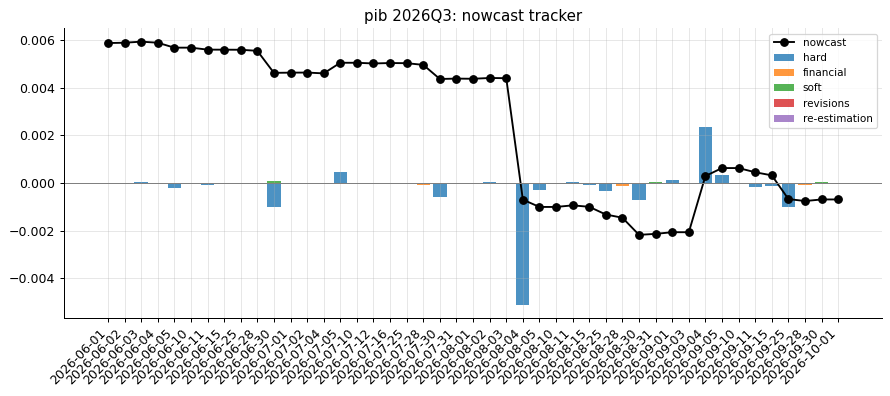

In [10]:
tracker = res.nowcast_tracker(panel, calendar, "2026Q3", "2026-06-01", "2026-10-01")
assert tracker.check_identity()
fig = tracker.plot("path")
show(fig, "07_tracker")

In [11]:
path = tracker.to_frame()
big = path.loc[path["change"].abs().nlargest(4).index].sort_index()
display(big[["nowcast", "change", "n_releases"]])
releases = tracker.releases()
for date in big.index:
    day = releases[releases["vintage"] == date]
    md(f"**{date.date()}**: " + ", ".join(sorted(set(day["series"]))))

,nowcast,change,n_releases
vintage,,,
2026-06-30,0.0046,-0.0009,4
2026-08-04,-0.0007,-0.0051,4
2026-09-04,0.0003,0.0024,4
2026-09-25,-0.0007,-0.0010,1


**2026-06-30**: anp_diesel, energia_consumo_industria, focus_ipca_12m, focus_pib

**2026-08-04**: pim_bens_capital, pim_bens_consumo_duraveis, pim_geral, pim_transformacao

**2026-09-04**: pim_bens_capital, pim_bens_consumo_duraveis, pim_geral, pim_transformacao

**2026-09-25**: arrecadacao_federal

Three of the four largest moves happen on the release days of IBGE's industrial
production survey (PIM-PF, early each month): hard data on activity in the quarter's
own months, with large weights. In particular the June figure (released on 4 August)
cut the nowcast by about half a percentage point and the July figure (4 September)
recovered part of it. Financial prices and Focus expectations, released daily or
weekly, cause frequent but small revisions.

## 6. Contributions to the *level* of the nowcast

News explains *changes*. The level of the nowcast can also be written as a baseline
(the unconditional mean) plus a contribution of every series, since the smoothed
target is linear in the data (innovation I6).

,contribution
series,
baseline,0.0057
pim_transformacao,-0.0024
pim_geral,-0.0017
anp_diesel,-0.0005
pib,-0.0004
ipea_consumo_aparente_industria,-0.0003
ibc_br,-0.0002
arrecadacao_federal,0.0002
credito_saldo_total,-0.0002


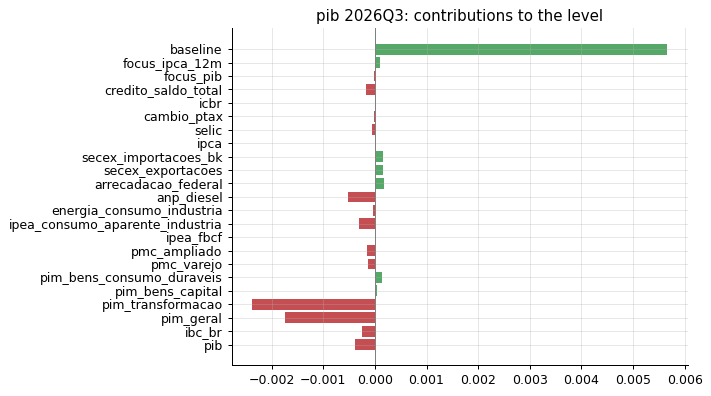

Nowcast 0.03% = baseline 0.57% + the sum of the series contributions.

In [12]:
level = res.level_contributions(new, "2026Q3")
assert level.check_identity()
contrib = level.to_frame()
display(contrib.sort_values("contribution", key=abs, ascending=False).head(10))
fig = level.plot("bar")
show(fig, "07_level")
md(
    f"Nowcast {pct(level.nowcast)} = baseline {pct(level.baseline)} + the sum of the "
    "series contributions."
)

### References

* Bańbura, M., Giannone, D. & Reichlin, L. (2011). Nowcasting. *Oxford Handbook of
  Economic Forecasting*, 193–224.
* Bańbura, M. & Modugno, M. (2014). Maximum likelihood estimation of factor models on
  datasets with arbitrary pattern of missing data. *Journal of Applied Econometrics*,
  29(1), 133–160.
* Bok, B., Caratelli, D., Giannone, D., Sbordone, A. M. & Tambalotti, A. (2018).
  Macroeconomic nowcasting and forecasting with big data. *Annual Review of
  Economics*, 10, 615–643.